In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, q_stat, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## Helper Functions

In [2]:
def ts_plot(series : pd.Series, max_lags : int, title : str):
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot the series
    axs[0, 0].plot(series)
    axs[0, 0].set_title('Series')

    # QQPLOT
    qqplot(series, ax = axs[0, 1], line='s')
    axs[0, 1].set_title('QQ plot')

    # ACF PLOT
    plot_acf(series, lags=max_lags, ax = axs[1, 0], zero=False) # zero = False to not include lag 0
    axs[1, 0].set_title('Autocorrelation plot')
    axs[1, 0].set_xlabel('Lag')

    # PACF PLOT
    plot_pacf(series, lags=max_lags, ax = axs[1, 1], zero=False)
    axs[1, 1].set_title('Partial Autocorrelation plot')
    axs[1, 1].set_xlabel('Lag')

    fig.suptitle(title, fontsize=20) # add a superior title for the figure
    # autoscale both correlation plots
    axs[1, 0].autoscale()
    axs[1, 1].autoscale()

In [3]:
def realised_volatility(
        log_ret: pd.Series,
        window: int = 21,
        annualise: bool = True,
        trading_periods: int = 252
    ) -> pd.Series:
    
    rv = log_ret.pow(2).rolling(window).sum()
    rv = rv.pow(0.5)
    if annualise:
        rv *= np.sqrt(trading_periods / window)

    return rv

In [4]:
def GarmanKlass(data : pd.DataFrame):
    
    # Extract the series length
    n = len(data)
    
    # Extract the adjusting coefficient
    coeff = data['Adj Close'] / data['Close'] #adjusting coefficient
    
    # Adjust the high low open close with the adjusting coefficient
    H = np.log(data['High'] * coeff)
    L = np.log(data['Low'] * coeff)
    O = np.log(data['Open'] * coeff)
    C = np.log(data['Close'] * coeff)
    
    # Calculate normalized returns
    u = (H - O) * 100 #between high and open
    d = (L - O) * 100 #between low and open
    c = (C - O) * 100 #between close and open
    
    ## Calculate the GK VARIANCE estimate
    x = 0.511 * (u - d)**2 + (-0.019) * (c * (u + d) - 2 * u * d) + (-0.383) * c**2
    
    # return the series
    return pd.Series(np.sqrt(x), index = data.index, name='Volatility') 



In [5]:
def GARCH_eval(model, name : str, realized_vol, annualized = False):

    results_df = {}

    #Create DF with GARCH-volatilities and realized volatilities

    if annualized == False:
        forecast = model.conditional_volatility.dropna() * 16
    else:
        forecast = model.conditional_volatility.dropna()

    if forecast.shape[0] != realized_vol.dropna().shape[0]:
        realized_vol = realized_vol[forecast.index.min():forecast.index.max()].dropna()
        forecast = forecast[realized_vol.index.min():realized_vol.index.max()]

    merged_df = pd.merge(realized_vol, forecast, left_index=True,
                         right_index=True, how='inner')
    
    #Calculate MAE, MSE, MAPE => y_pred, y_actual
    results_df['MAE'] = mean_absolute_error(merged_df.iloc[:,1], merged_df.iloc[:, 0])
    results_df['MSE'] = mean_squared_error(merged_df.iloc[:,1], merged_df.iloc[:,0])
    results_df['MAPE'] = mean_absolute_percentage_error(merged_df.iloc[:,1], merged_df.iloc[:,0])

    #Model IC Metrics
    results_df['AIC'] = model.aic
    results_df['BIC'] = model.bic

    results_df = pd.DataFrame(results_df, index = [name])

    return results_df

## Set Up

In [7]:
df_CRSP = pd.read_csv(r'C:\Users\Phillip\Desktop\Python\Python Notebooks (Mine)\Datasets\CRSP_B.csv', index_col = [1], parse_dates = True)
df_CRSP.columns = ['PERMNO', 'TICKER', 'NASDAQ INDEX', 'PRICE', 'RETURNS']
df_CRSP_B = df_CRSP.copy().loc[:, ['TICKER', 'PRICE']]

In [9]:
def log_rets(df):
    
    df['LOG RETS'] = np.log(df['PRICE'] / df['PRICE'].shift()) * 100
    df['SQUARED RETS'] = df['LOG RETS'] ** 2 
    df.dropna(subset=['LOG RETS'], inplace = True)
    df = df.drop('TICKER', axis = 1)
    return df

In [ ]:
MSFT = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'MSFT']
AAPL = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'AAPL']
META = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'META']
AMZN = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'AMZN']
NVDA = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'NVDA']
GOOGL = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'GOOGL']
TSLA = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'TSLA']

MAG7 = [MSFT, AAPL, META, AMZN, NVDA, GOOGL, TSLA]
df = { str(x.iloc[0, 0]) : log_rets(x) for x in MAG7}

In [11]:
MSFT = df['MSFT']
AAPL = df['MSFT']
META = df['META']
AMZN = df['AMZN']
NVDA = df['NVDA']
GOOGL = df['GOOGL']
TSLA = df['TSLA']

In [ ]:
def datasplit(training_size, df):

    train_df = df[-(training_size):]
    test_df = df[:-(training_size)]

    return train_df, test_df

## Initial Visualisations

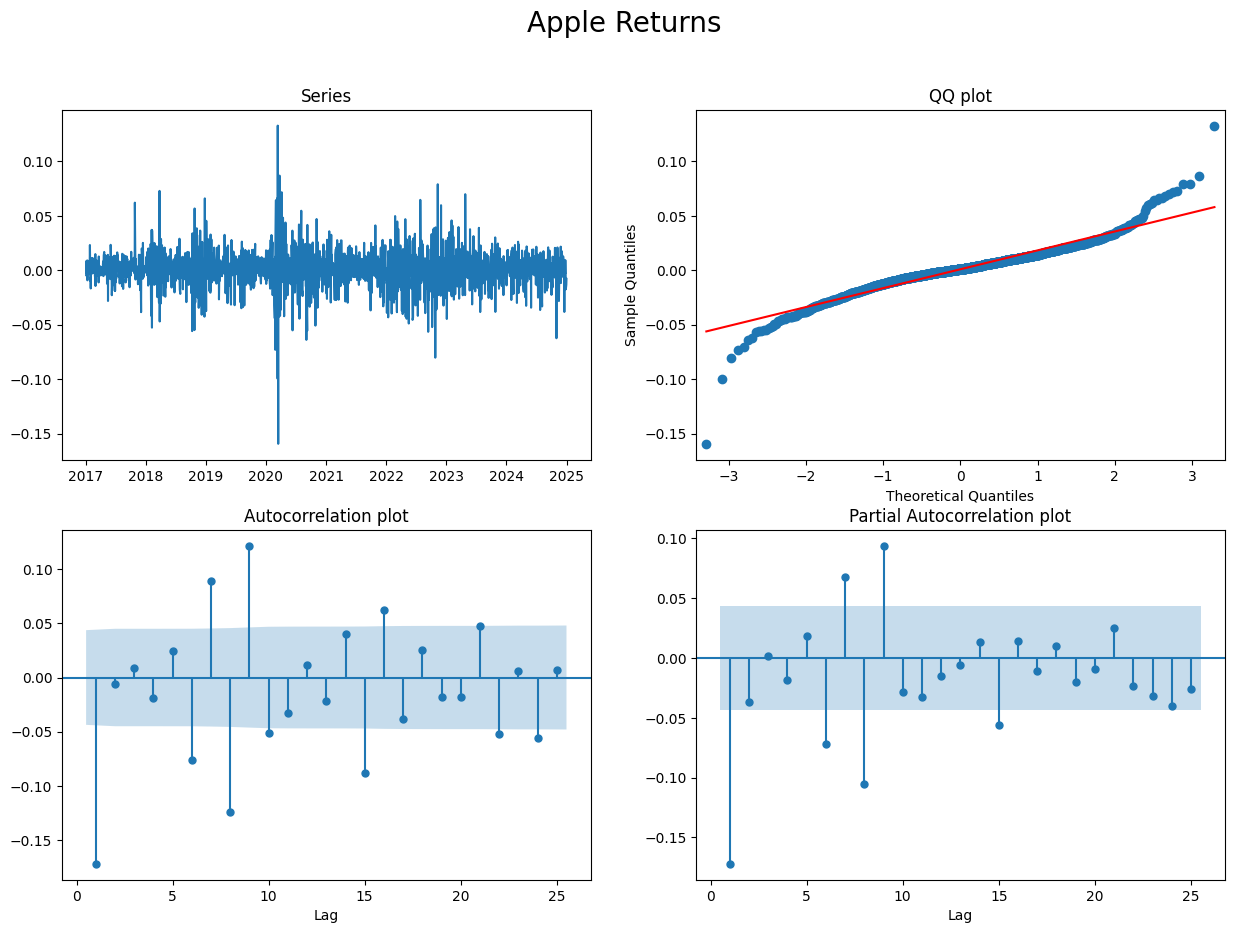

In [12]:
ts_plot(AAPL['LOG RETS'] / 100, 25, 'Apple Returns')

Text(0.5, 1.0, 'AAPL Monthly Realised Volatility')

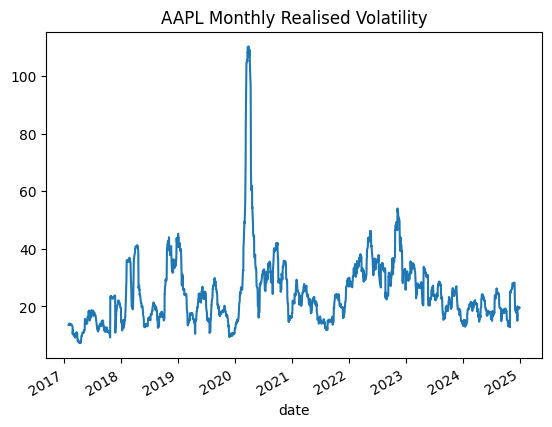

In [13]:
#Realised Vol Plot
AAPL_realised_vol = realised_volatility(AAPL['LOG RETS'], 21, 252)
AAPL_realised_vol.plot()
plt.title('AAPL Monthly Realised Volatility')

## GARCH 

    - Returns should be integer % values (required by arch library). 
    - Realised volatility : use formula based estimators (Garman Klass) or actual realized vol

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

In [83]:
#Split Date at June 2024
split_date = dt.datetime(2024, 6, 1)

In [84]:
AAPL_GARCH = arch_model(AAPL['LOG RETS'],
                        p = 1 , q = 1,
                        mean = 'AR',
                        lags = 1,
                        vol = 'GARCH',
                        dist = 'normal')

AAPL_GARCH_Result = AAPL_GARCH.fit(update_freq=0, last_obs = split_date, disp='on')

In [85]:
AAPL_GARCH_Result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:               LOG RETS   R-squared:                       0.026
Mean Model:                        AR   Adj. R-squared:                  0.025
Vol Model:                      GARCH   Log-Likelihood:               -3422.36
Distribution:                  Normal   AIC:                           6854.73
Method:            Maximum Likelihood   BIC:                           6882.38
                                        No. Observations:                 1863
Date:                Wed, May 14 2025   Df Residuals:                     1861
Time:                        22:15:38   Df Model:                            2
                                 Mean Model                                 
============================================================================
                  coef    std err          t      P>|t|     95.0% Conf. Int.
----------------------------------------------------------------------------
Const           0.1484  3.137e-02      4.730  2.247e-06  [8.690e-02,  0.210]
LOG RETS[1]    -0.1015  2.676e-02     -3.793  1.487e-04 [ -0.154,-4.906e-02]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.0881  5.213e-02      1.689  9.117e-02 [-1.411e-02,  0.190]
alpha[1]       0.1131  3.458e-02      3.271  1.071e-03  [4.534e-02,  0.181]
beta[1]        0.8580  4.660e-02     18.412  1.062e-75    [  0.767,  0.949]
===========================================================================

Covariance estimator: robust
"""

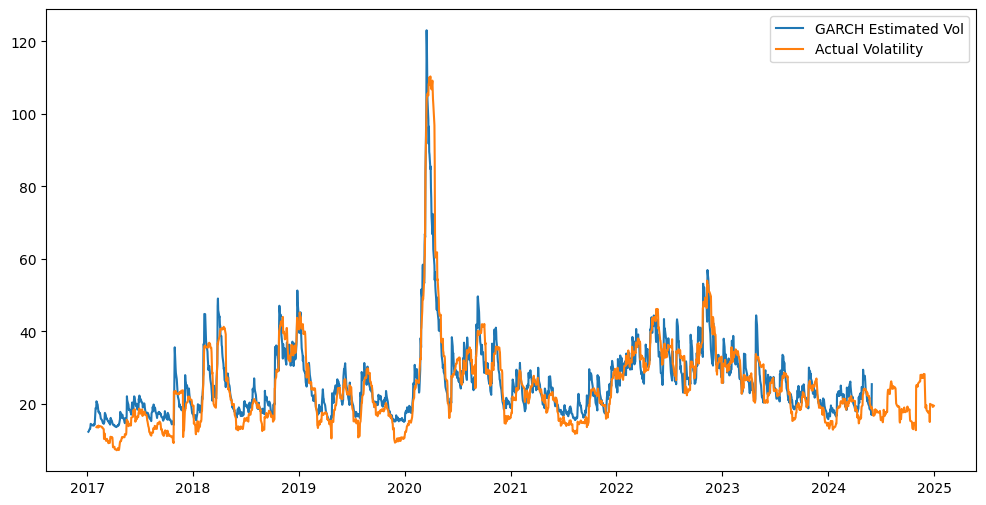

In [86]:
# Must make sure the volatility units are the same - the RV function calculates annualised
# ARCH model gives what whatever format we fed it via the DF
Annualised_Conditional_Vols_GARCH = AAPL_GARCH_Result.conditional_volatility.dropna() * 16

plt.figure(figsize=(12,6))
plt.plot(Annualised_Conditional_Vols_GARCH, label = 'GARCH Estimated Vol')
plt.plot(AAPL_realised_vol, label = 'Actual Volatility')
plt.legend()

### GARCH Model Validation

Check the standardised SQUARED residuals to see if there is any structure left we haven't taken in via our model.

Note
    - Fat tails in QQ Plot => U shaped => asymmetric suggests a different distribution is needed to model the residuals
    - But GARCH model has removed serial correlation in the squared residuals relatively successfully from the plot
    - But must use Ljung Box statistics for squared and normal standardised residuals

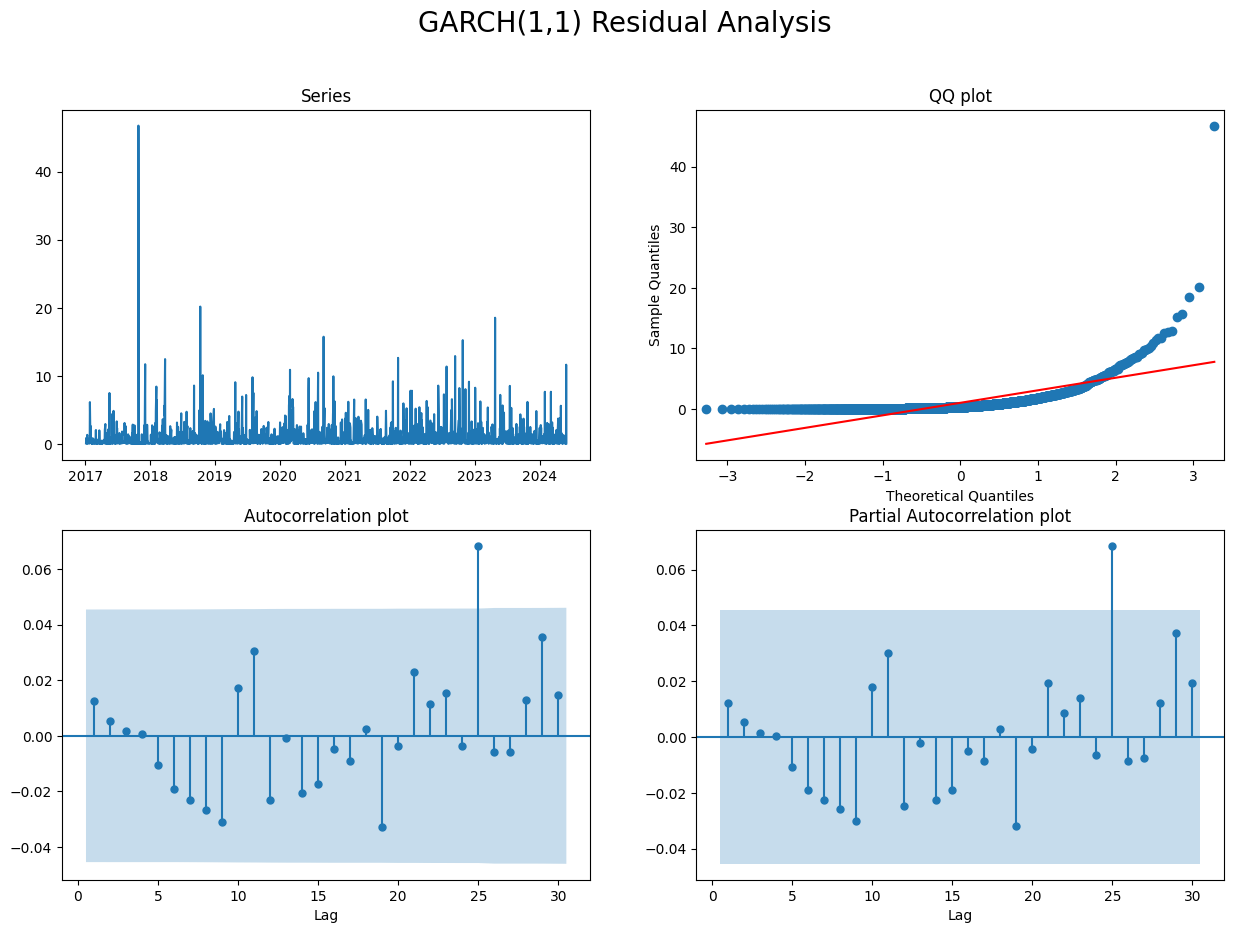

In [87]:
ts_plot(AAPL_GARCH_Result.std_resid.dropna() ** 2, max_lags = 30,
        title='GARCH(1,1) Residual Analysis')

In [88]:
residual_ljungbox = sm.stats.acorr_ljungbox(AAPL_GARCH_Result.std_resid.dropna(), lags=None)
squared_residual_ljungbox = sm.stats.acorr_ljungbox(AAPL_GARCH_Result.std_resid.dropna() ** 2, lags = None)

In [89]:
residual_ljungbox.T

,1,2,3,4,5,6,7,8,9,10
lb_stat,0.325379,6.165237,6.165283,6.165792,6.544742,8.783796,9.498142,12.501766,13.465139,13.465734
lb_pvalue,0.568393,0.045839,0.103840,0.187104,0.256758,0.186107,0.218841,0.130181,0.142664,0.198785


In [90]:
squared_residual_ljungbox.T

,1,2,3,4,5,6,7,8,9,10
lb_stat,0.285597,0.339995,0.344715,0.345178,0.552046,1.246436,2.258505,3.584035,5.381687,5.932289
lb_pvalue,0.593056,0.843667,0.951411,0.986714,0.990093,0.974529,0.944159,0.892571,0.799848,0.820920


The ljung box test exclude now autocorrelation from the standardized residuals, however, when looking at the test statistic for the squared of the standardized residuals, there is still persistence of some kind of correlation after lag 2, since all the remaining lags reject the null hypotheses of absence of autocorrelation. 

This means that there are some remaining patterns or structures in the volatility that are not adequately captured by the model. 

## Changing Distribution to Specify Residuals

### T Student Distribution

In [91]:
# Try with t student distribution

garch_T_result = arch_model(AAPL['LOG RETS'], 
                   mean = 'AR',  # mean process
                   lags=1, # order of the mean process
                   vol = 'GARCH',  # variance process
                   p = 1,
                   q = 1,
                   dist = 't' # underlying (by hypotheses) distribution of the standardized residuals
                   ).fit(update_freq=0, last_obs=split_date, disp='off')

garch_T_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              AR - GARCH Model Results                              
====================================================================================
Dep. Variable:                     LOG RETS   R-squared:                       0.023
Mean Model:                              AR   Adj. R-squared:                  0.022
Vol Model:                            GARCH   Log-Likelihood:               -3367.25
Distribution:      Standardized Student's t   AIC:                           6746.50
Method:                  Maximum Likelihood   BIC:                           6779.68
                                              No. Observations:                 1863
Date:                      Wed, May 14 2025   Df Residuals:                     1861
Time:                              22:16:00   Df Model:                            2
                                 Mean Model                                 
============================================================================
                  coef    std err          t      P>|t|     95.0% Conf. Int.
----------------------------------------------------------------------------
Const           0.1678  2.776e-02      6.046  1.487e-09    [  0.113,  0.222]
LOG RETS[1]    -0.0869  2.406e-02     -3.612  3.039e-04 [ -0.134,-3.974e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0508  2.380e-02      2.135  3.279e-02 [4.156e-03,9.744e-02]
alpha[1]       0.1190  2.733e-02      4.353  1.341e-05   [6.541e-02,  0.173]
beta[1]        0.8727  2.955e-02     29.533 1.102e-191     [  0.815,  0.931]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.6883      0.731      7.778  7.376e-15 [  4.255,  7.122]
========================================================================

Covariance estimator: robust
"""

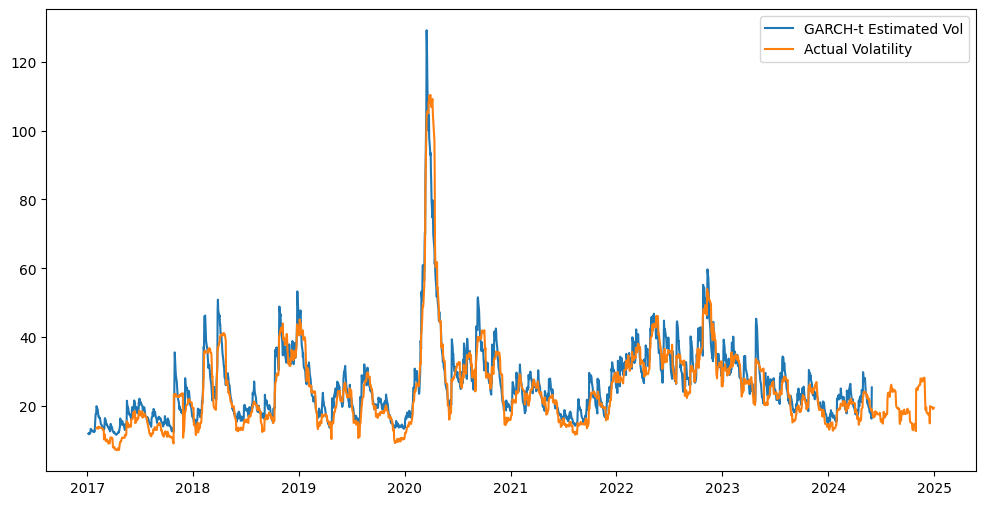

In [106]:
Annualised_Conditional_Vols_GARCH_t = garch_T_result.conditional_volatility.dropna() * 16

plt.figure(figsize=(12,6))
plt.plot(Annualised_Conditional_Vols_GARCH_t, label = 'GARCH-t Estimated Vol')
plt.plot(AAPL_realised_vol, label = 'Actual Volatility')
plt.legend()

### Skewed T Distribution

In [93]:
# Try with skewed t distribution
garch_skwT_result = arch_model(AAPL['LOG RETS'], 
                   mean = 'AR',  # mean process
                   lags=1, # order of the mean process
                   vol = 'GARCH',  # variance process
                   p = 1,
                   q = 1,
                   dist = 'skewt' # underlying (by hypotheses) distribution of the standardized residuals
                   ).fit(update_freq=0, last_obs=split_date, disp='off')

garch_skwT_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 AR - GARCH Model Results                                
=========================================================================================
Dep. Variable:                          LOG RETS   R-squared:                       0.024
Mean Model:                                   AR   Adj. R-squared:                  0.024
Vol Model:                                 GARCH   Log-Likelihood:               -3365.10
Distribution:      Standardized Skew Student's t   AIC:                           6744.21
Method:                       Maximum Likelihood   BIC:                           6782.92
                                                   No. Observations:                 1863
Date:                           Wed, May 14 2025   Df Residuals:                     1861
Time:                                   22:16:03   Df Model:                            2
                                 Mean Model                                 
============================================================================
                  coef    std err          t      P>|t|     95.0% Conf. Int.
----------------------------------------------------------------------------
Const           0.1476  2.933e-02      5.031  4.867e-07  [9.009e-02,  0.205]
LOG RETS[1]    -0.0913  2.446e-02     -3.735  1.876e-04 [ -0.139,-4.341e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0545  2.510e-02      2.172  2.984e-02 [5.329e-03,  0.104]
alpha[1]       0.1204  2.772e-02      4.345  1.394e-05 [6.611e-02,  0.175]
beta[1]        0.8687  3.076e-02     28.240 1.880e-175   [  0.808,  0.929]
                               Distribution                               
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
eta            5.9427      0.837      7.104  1.213e-12   [  4.303,  7.582]
lambda        -0.0678  3.465e-02     -1.958  5.028e-02 [ -0.136,8.144e-05]
==========================================================================

Covariance estimator: robust
"""

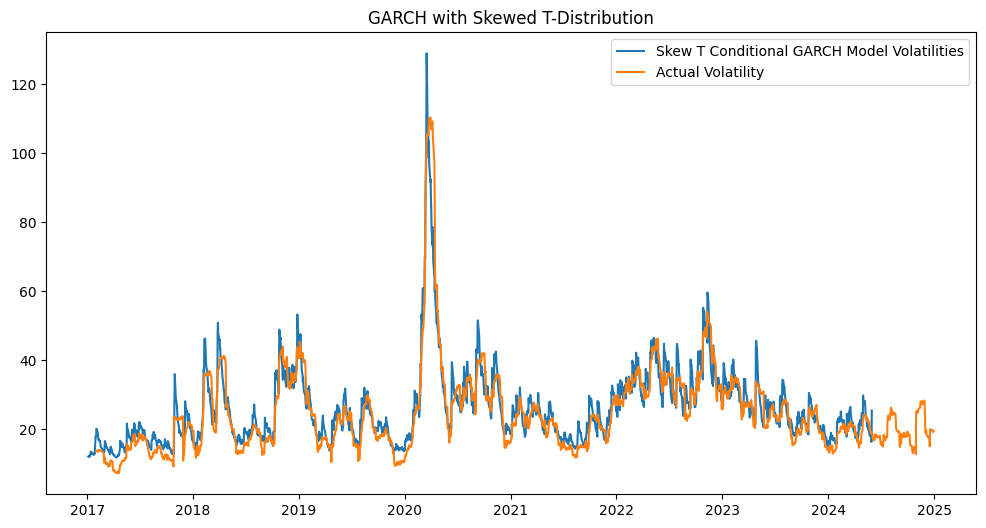

In [94]:
Garch_TSkew_Conditional_Vols = garch_skwT_result.conditional_volatility.dropna() * 16

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(Garch_TSkew_Conditional_Vols, label = 'Skew T Conditional GARCH Model Volatilities')
ax.plot(AAPL_realised_vol, label = 'Actual Volatility')
plt.title('GARCH with Skewed T-Distribution')
plt.legend()
plt.show();

### Model Evaluation of GARCH with different distributions

GARCH(1,1) with T Distribution and Skewed T was quite similar for Apple. But is better than using GARCH with normal assumption.

In [95]:
model_eval = pd.concat([GARCH_eval(AAPL_GARCH_Result, name = 'GARCH(1,1)', realized_vol=AAPL_realised_vol),
                        GARCH_eval(garch_skwT_result, name='GARCH(1,1) Skewed T-Dist', realized_vol=AAPL_realised_vol),
                        GARCH_eval(garch_T_result, name = 'GARCH(1,1) T-Dist', realized_vol=AAPL_realised_vol)]
                        )

model_eval.round(3)

,MAE,MSE,MAPE,AIC,BIC
"GARCH(1,1)",3.631,25.379,0.146,6854.728,6882.378
"GARCH(1,1) Skewed T-Dist",3.341,21.000,0.131,6744.208,6782.917
"GARCH(1,1) T-Dist",3.309,20.280,0.130,6746.495,6779.675


# Asymmetric Volatility Modelling

## EGARCH

The exponential generalized autoregressive conditional heteroskedastic (EGARCH) model was developed by Nelson & Cao in 1991. In particular, to allow for asymmetric effects between positive and negative asset returns, the model considers a weighted innovation:

$$g(\epsilon_t) = \theta\epsilon_t + \gamma[|\epsilon_t| - E(|\epsilon_t|)] \ \ \ \ (1)$$

where both $\epsilon_t$ and $(|\epsilon_t| - E(|\epsilon_t|))$ are zero iid sequences. 
These formulation of $g(\epsilon_t)$ allows the sign and magnitude of $\epsilon_t$ to have a separate effect on the volatility.

Formally, an EGARCH(p,q) is defined as:

$$ \log{\sigma^2}_t = \omega + \sum^q_{k=1}{\beta_kg(\epsilon_{t-k})} + \sum^p_{k=1}{\alpha_k}\log{\sigma^2}_{t-k} \ \ \ \ (2)$$

Since $\log{\sigma^2}_t$ could be negative, no restrictions are applied to the parameters. 



In [96]:
#EGARCH 
EGARCH_skewT_result_AAPL = arch_model(AAPL['LOG RETS'],
                                    mean = 'AR', 
                                    lags = 1,
                                    vol = 'EGARCH',
                                    o = 1, #Lag Order of Asymmetric Innovation Term
                                    p = 1, #Lag Order of Symmetric Innovation
                                    q = 1, #Lag order of Prior Vol/Variance
                                    dist = 'skewt'
                                    ).fit(disp='off', last_obs=split_date)


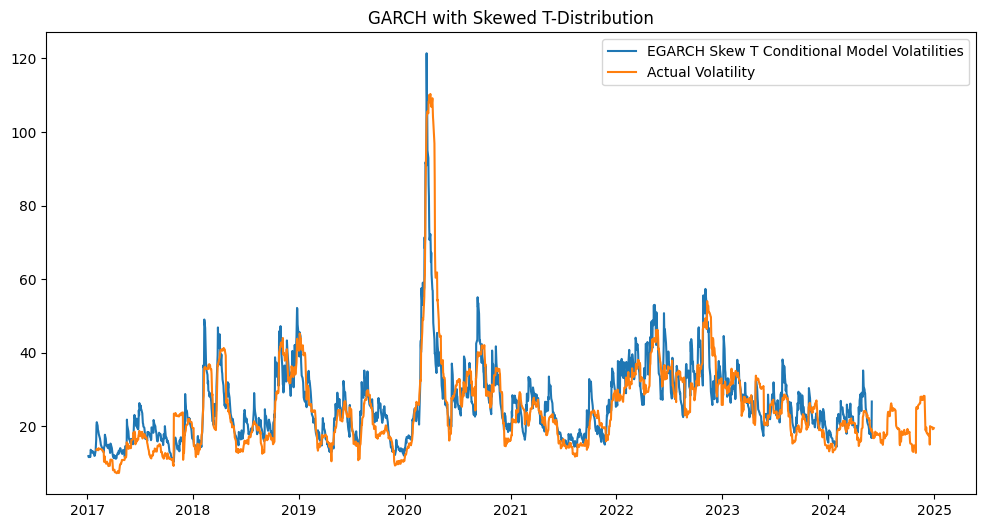

In [97]:
EGARCH_Conditional_Vols = EGARCH_skewT_result_AAPL.conditional_volatility.dropna() * 16

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(EGARCH_Conditional_Vols, label = 'EGARCH Skew T Conditional Model Volatilities')
ax.plot(AAPL_realised_vol, label = 'Actual Volatility')
plt.title('GARCH with Skewed T-Distribution')
plt.legend()
plt.show();

In [98]:
EGARCH_skewT_result_AAPL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                AR - EGARCH Model Results                                
=========================================================================================
Dep. Variable:                          LOG RETS   R-squared:                       0.023
Mean Model:                                   AR   Adj. R-squared:                  0.022
Vol Model:                                EGARCH   Log-Likelihood:               -3350.41
Distribution:      Standardized Skew Student's t   AIC:                           6716.81
Method:                       Maximum Likelihood   BIC:                           6761.05
                                                   No. Observations:                 1863
Date:                           Wed, May 14 2025   Df Residuals:                     1861
Time:                                   22:16:09   Df Model:                            2
                                 Mean Model                                 
============================================================================
                  coef    std err          t      P>|t|     95.0% Conf. Int.
----------------------------------------------------------------------------
Const           0.1068  3.038e-02      3.516  4.383e-04  [4.726e-02,  0.166]
LOG RETS[1]    -0.0820  2.372e-02     -3.456  5.476e-04 [ -0.128,-3.550e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0388  1.140e-02      3.406  6.592e-04 [1.648e-02,6.115e-02]
alpha[1]       0.2068  3.159e-02      6.547  5.867e-11     [  0.145,  0.269]
gamma[1]      -0.1045  2.238e-02     -4.669  3.020e-06  [ -0.148,-6.063e-02]
beta[1]        0.9671  9.377e-03    103.137      0.000     [  0.949,  0.986]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta            5.9517      0.874      6.811  9.695e-12    [  4.239,  7.664]
lambda        -0.0888  3.460e-02     -2.565  1.030e-02 [ -0.157,-2.095e-02]
===========================================================================

Covariance estimator: robust
"""

In [99]:
#LB Test
sm.stats.acorr_ljungbox(EGARCH_skewT_result_AAPL.std_resid.dropna() ** 2, lags=None)

,lb_stat,lb_pvalue
1,0.000102,0.991961
2,0.002190,0.998905
3,0.086117,0.993450
4,0.106038,0.998643
5,0.106414,0.999811
6,0.839647,0.990968
7,1.622422,0.977766
8,2.422735,0.965237
9,3.371357,0.947738
10,3.379736,0.971025


In [100]:
model_eval = pd.concat([model_eval, 
                        GARCH_eval(EGARCH_skewT_result_AAPL,
                                   name = 'EGARCH(1,1,1) with skewed T',
                                   realized_vol = AAPL_realised_vol)])

model_eval

,MAE,MSE,MAPE,AIC,BIC
"GARCH(1,1)",3.631036,25.379281,0.145726,6854.728273,6882.377990
"GARCH(1,1) Skewed T-Dist",3.340747,20.999516,0.131332,6744.207685,6782.917288
"GARCH(1,1) T-Dist",3.309253,20.279926,0.129773,6746.495394,6779.675055
"EGARCH(1,1,1) with skewed T",4.381270,42.638710,0.166714,6716.814407,6761.053954


## GJR GARCH

For a GJR-GARCH(1,1), the variance process is:

$$\sigma^2_t =  \omega + \alpha_1\epsilon^2_{t-1} + \gamma_1\epsilon^2_{t-1}I_{t-1} + \beta_1\sigma^2_{t-1} $$

where $I_{t-1}$ is an indicator function that:

$$ I_{t-1} = \begin{cases} 1 &\text{if } \epsilon_{t-1} < 0 \\ 0 &\text{if } \epsilon_{t-1} \ge 0 \end{cases} $$

By implementing the indicator function in the volatility process the model gives one extra parameters $\gamma_1$ that emphasises the effect of negative past news on the conditional volatility and allows the model to better retrace the asymmetry in the volatility.

In [101]:
#GJR GARCH is GARCH with o = 1
GJR_GARCH_Result = arch_model(AAPL['LOG RETS'], 
                            vol = 'GARCH',
                            o = 1,
                            p = 1, #What makes it GJR GARCH
                            q = 1,
                            dist = 'skewt',
                            mean = 'AR',
                            lags = 1).fit(disp='off', last_obs=split_date)

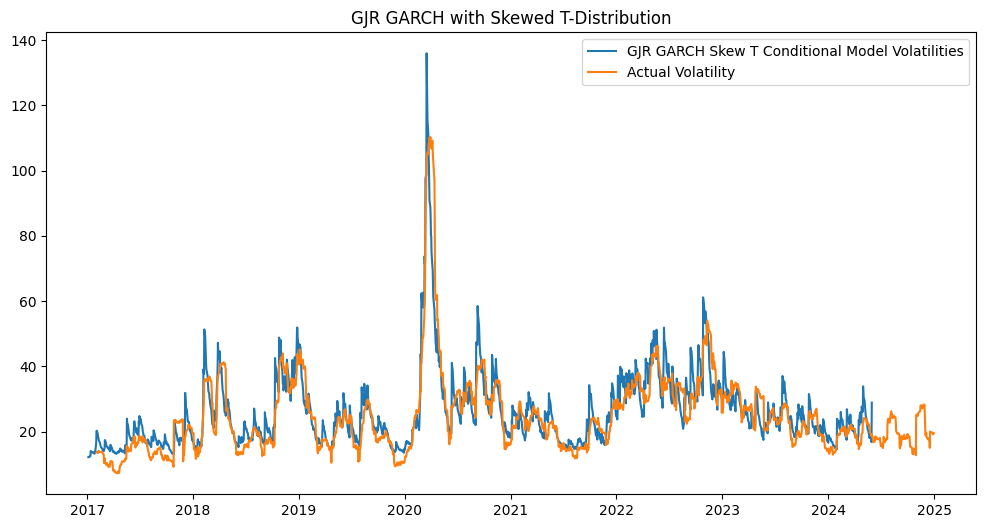

In [102]:
GJR_GARCH_Cond_Vols = GJR_GARCH_Result.conditional_volatility.dropna() * 16

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(GJR_GARCH_Cond_Vols, label = 'GJR GARCH Skew T Conditional Model Volatilities')
ax.plot(AAPL_realised_vol, label = 'Actual Volatility')
plt.title('GJR GARCH with Skewed T-Distribution')
plt.legend()
plt.show();

In [103]:
GJR_GARCH_Result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               AR - GJR-GARCH Model Results                              
=========================================================================================
Dep. Variable:                          LOG RETS   R-squared:                       0.023
Mean Model:                                   AR   Adj. R-squared:                  0.023
Vol Model:                             GJR-GARCH   Log-Likelihood:               -3354.56
Distribution:      Standardized Skew Student's t   AIC:                           6725.12
Method:                       Maximum Likelihood   BIC:                           6769.36
                                                   No. Observations:                 1863
Date:                           Wed, May 14 2025   Df Residuals:                     1861
Time:                                   22:16:16   Df Model:                            2
                                 Mean Model                                 
============================================================================
                  coef    std err          t      P>|t|     95.0% Conf. Int.
----------------------------------------------------------------------------
Const           0.1157  3.041e-02      3.805  1.416e-04  [5.611e-02,  0.175]
LOG RETS[1]    -0.0855  2.444e-02     -3.497  4.704e-04 [ -0.133,-3.756e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0661  2.465e-02      2.682  7.312e-03    [1.781e-02,  0.114]
alpha[1]       0.0355  2.283e-02      1.554      0.120 [-9.270e-03,8.023e-02]
gamma[1]       0.1387  3.691e-02      3.758  1.712e-04    [6.636e-02,  0.211]
beta[1]        0.8766  2.881e-02     30.428 2.362e-203      [  0.820,  0.933]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta            5.9987      0.840      7.139  9.394e-13    [  4.352,  7.646]
lambda        -0.0873  3.474e-02     -2.512  1.200e-02 [ -0.155,-1.919e-02]
===========================================================================

Covariance estimator: robust
"""

In [104]:
sm.stats.acorr_ljungbox(GJR_GARCH_Result.std_resid.dropna() ** 2, lags=None)

,lb_stat,lb_pvalue
1,0.100624,0.751083
2,0.102583,0.950002
3,0.123788,0.988837
4,0.129168,0.998002
5,0.439663,0.994166
6,1.674560,0.947068
7,2.964101,0.888303
8,4.344670,0.824765
9,6.437240,0.695484
10,6.440277,0.777017


In [105]:
model_eval = pd.concat([model_eval, 
                        GARCH_eval(GJR_GARCH_Result,
                                   name = 'GJR GARCH(1,1,1) with skewed T',
                                   realized_vol = AAPL_realised_vol)])

model_eval

,MAE,MSE,MAPE,AIC,BIC
"GARCH(1,1)",3.631036,25.379281,0.145726,6854.728273,6882.377990
"GARCH(1,1) Skewed T-Dist",3.340747,20.999516,0.131332,6744.207685,6782.917288
"GARCH(1,1) T-Dist",3.309253,20.279926,0.129773,6746.495394,6779.675055
"EGARCH(1,1,1) with skewed T",4.381270,42.638710,0.166714,6716.814407,6761.053954
"GJR GARCH(1,1,1) with skewed T",4.090868,32.743713,0.155875,6725.116025,6769.355572


## Forecasting OOS

In [112]:
EGARCH_Forecast = EGARCH_skewT_result_AAPL.forecast(reindex=False)

#Extract Forecasted Volatilities
EGARCH_Forecasted_Vols = np.sqrt(EGARCH_Forecast.variance) 

#Column h1 is the forecasted volatility for the day after
EGARCH_Forecasted_Vols.head(3)

,h.1
date,
2024-05-31,1.581371
2024-06-03,1.534187
2024-06-04,1.442989


In [109]:
# Must shift the volatilities by 1 day back so the date index are aligned with 
# actual volatility
EGARCH_Forecasted_Vols = EGARCH_Forecasted_Vols.shift().dropna()

In [114]:
EGARCH_Forecasted_Vols.head(3)

,h.1
date,
2024-05-31,1.581371
2024-06-03,1.534187
2024-06-04,1.442989


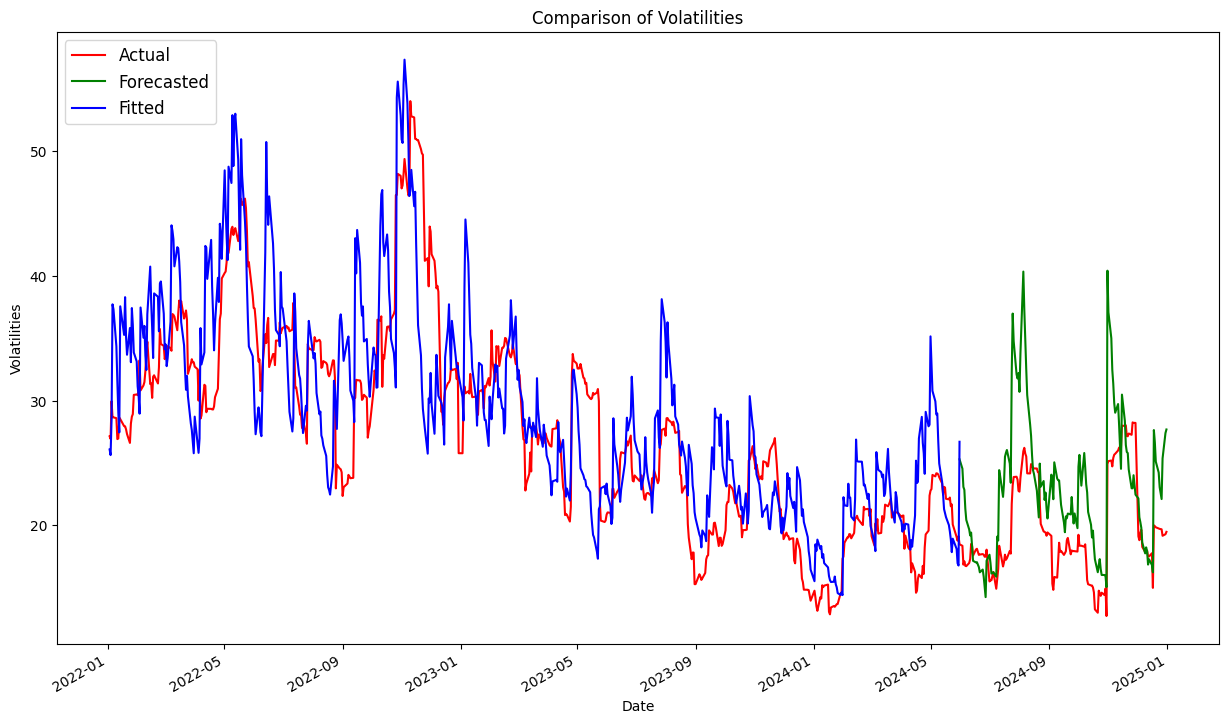

In [125]:
#Plot the realized volatility against EGARCH fitted volatilities + Forecasted Volatilities

#Will start the plot from 2022 just to zoom in 
start = '2022-01-01'

plt.figure(figsize = (15, 9))
plt.plot(AAPL_realised_vol[start:], label = 'Actual Volatility', color = 'red', linewidth = 1.5)
plt.plot(EGARCH_Forecasted_Vols * 16, label = 'Forecasted Volatility', color = 'green', linewidth = 1.5)
plt.plot(EGARCH_Conditional_Vols[start:], label = 'EGARCH Fitted Volatilities', color='blue', linewidth = 1.5)

plt.gcf().autofmt_xdate()
plt.title('Comparison of Volatilities')
plt.xlabel('Date')
plt.ylabel('Volatilities')
plt.legend(['Actual', 'Forecasted', 'Fitted'], loc = 'upper left', fontsize = 12)
plt.show();

## Rolling GARCH

In [ ]:
AAPL_index = AAPL.index
start_loc = 0
end_loc = np.where(AAPL_index >= '2024-12-31')[0].min() - 250
AAPL_forecast_variances = {}
AAPL_GARCH_Rolling = arch_model(AAPL['LOG RETS'], p = 1, q = 1, vol = 'GARCH')

In [ ]:
AAPL_index = AAPL.index
start_loc = 0
end_loc = np.where(AAPL_index >= '2024-12-31')[0].min() - 250
AAPL_forecast_variances = {}
AAPL_GARCH_Rolling = arch_model(AAPL['LOG RETS'], p = 1, q = 1, vol = 'GARCH')

for i in range(250):
    results = AAPL_GARCH_Rolling.fit(first_obs = i, last_obs = end_loc + i, disp = 'off')
    temp = results.forecast(horizon = 1).variance
    fcast = temp.iloc[0]
    AAPL_forecast_variances[fcast.name] = fcast
    if fcast.name == AAPL.index[-1]:
        print(i)
        break


In [ ]:
AAPL_forecast_variances_df = pd.DataFrame(AAPL_forecast_variances.values(), index = AAPL_forecast_variances.keys())

Text(0.5, 1.0, 'Rolling Predictions vs Actual')

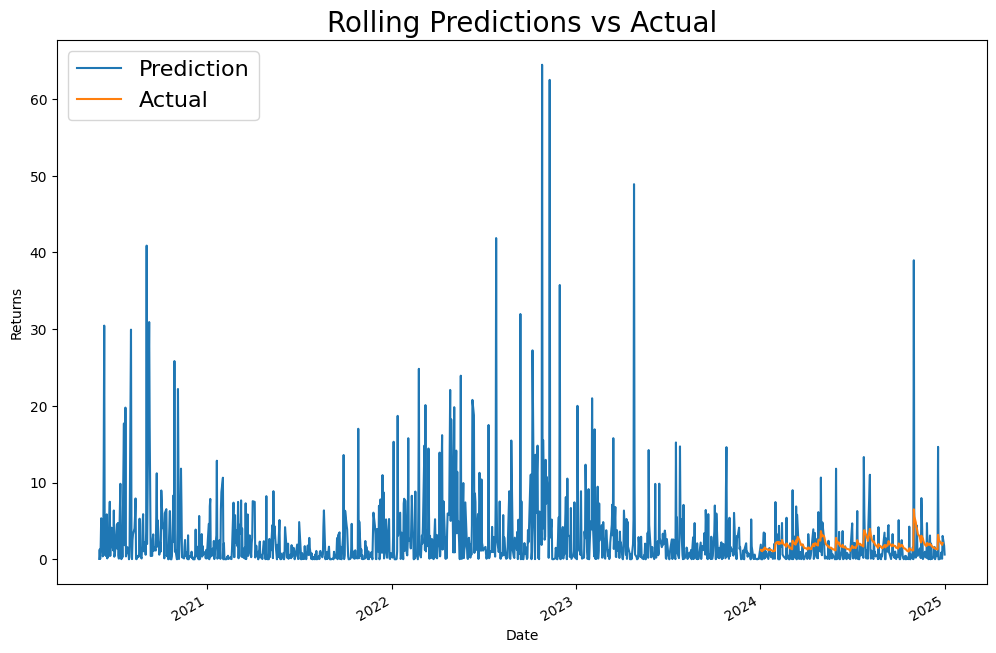

In [ ]:
#Plot Predictions
fig, ax = plt.subplots(figsize = (12,8))
plt.xlabel('Date')
plt.ylabel('Returns')
plt.gcf().autofmt_xdate()
plt.plot(AAPL['SQUARED RETS'].loc['2020-06-01':], label = 'Actual Squared Returns')
plt.plot(AAPL_forecast_variances_df.loc['2020-06-01':], label = 'Predicted Squared Returns')
plt.legend(['Prediction', 'Actual'], loc = 'upper left', fontsize = 16)
plt.title('Rolling Predictions vs Actual', fontsize = 20)

## Tests for Autocorrelation Squared Returns

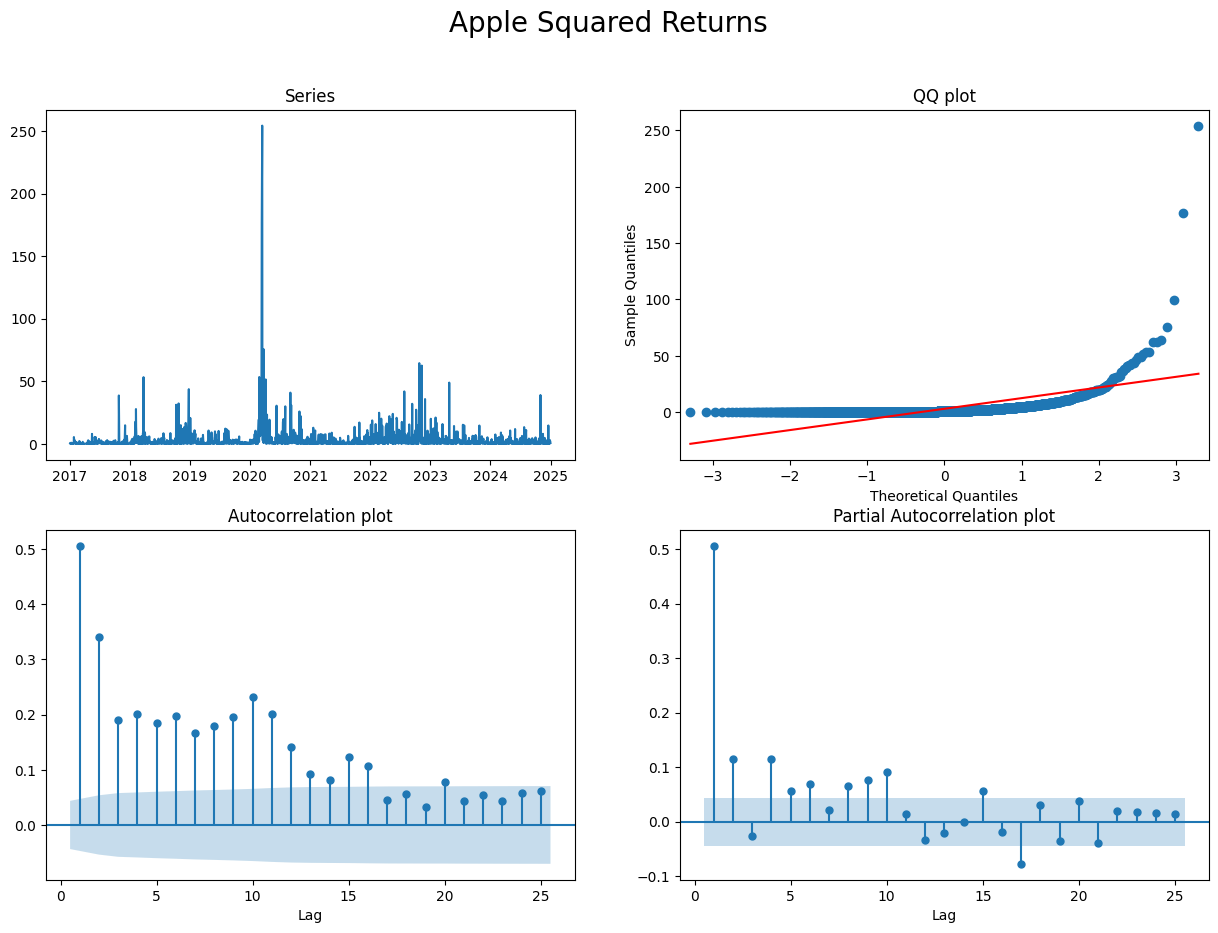

In [ ]:
#Visualisation shows autocorrelation structure exists in squared returns
ts_plot(AAPL['SQUARED RETS'], 25, 'Apple Squared Returns')

#### Ljung-Box test 

Another way to check the presence of autocorrelation in the data is using the Ljung Box test statistic, for which:

- $H_0$ : The data are independently distributed; No Autocorrelation
- $H_1$ : The data are not independently distributed; they exhibit serial correlation.

In [ ]:
#Use Ljung Box Test
LjungBox = sm.stats.acorr_ljungbox(AAPL['SQUARED RETS'], lags=None, auto_lag=True)
LjungBox.head()

,lb_stat,lb_pvalue
1,516.120162,2.955684e-114
2,750.645788,9.984773e-164
3,824.131736,2.526572e-178
4,905.119776,1.295307e-194
5,973.524041,3.240537e-208


In [ ]:
print('Number of Violations (when p-value is above 5%) :', (LjungBox['lb_pvalue'] > 0.05).sum())

Number of Violations (when p-value is above 5%) : 0


#### Analysis of Apple's Returns

Now that we can conclude there does exist autocorrelation within squared returns, we look into the returns distribution

In [ ]:
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

returns = AAPL['LOG RETS'] / 100

In [ ]:
sns.set(style="darkgrid", color_codes=True)

Text(0.5, 1.0, '2nd anomaly: higher spike of AAPL returns distribution')

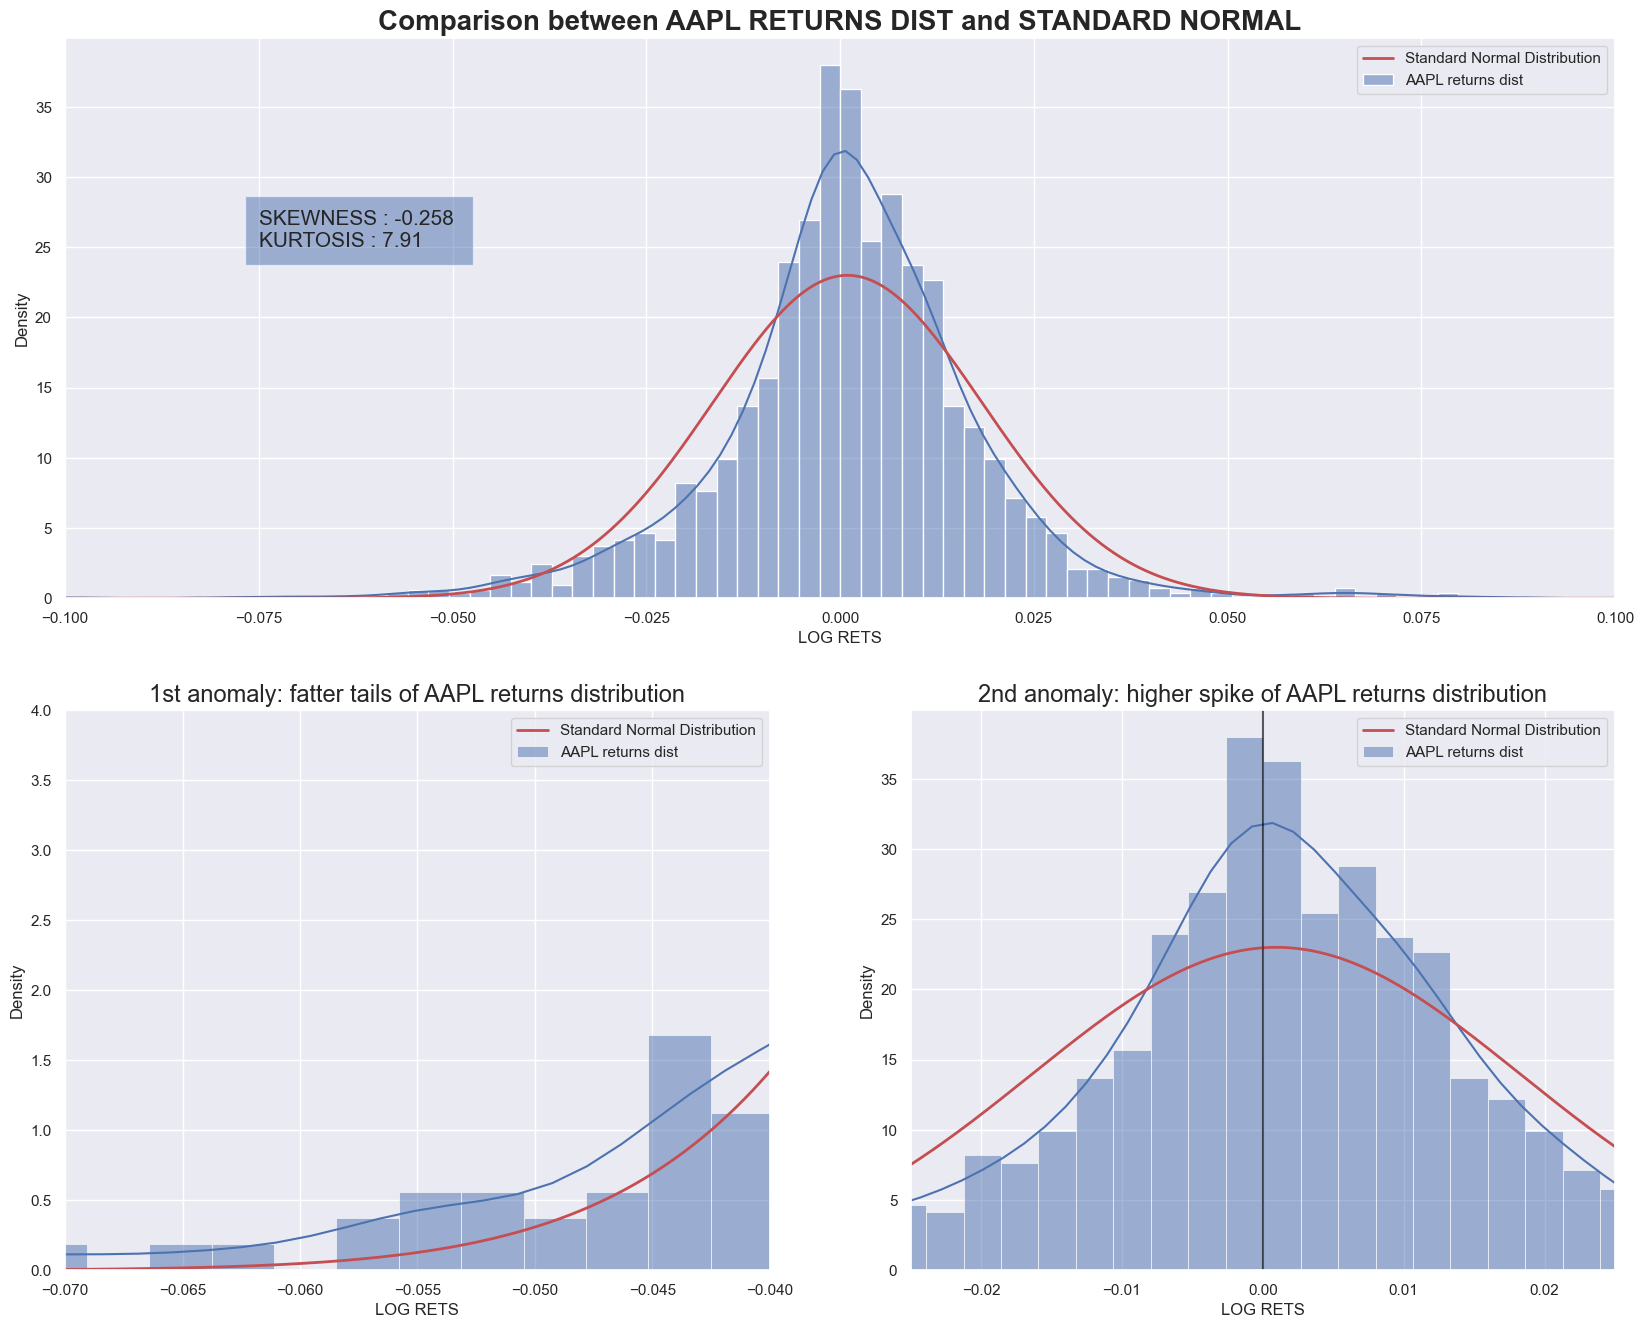

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

gs = fig.add_gridspec(2, 2)
ax = fig.add_subplot(gs[0, :]) # add one subplot in the two grids of the first row
axs[0, 0].set_yticks([]) 
axs[0, 0].set_xticks([])
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])


sns.histplot(returns, stat='density', kde=True, label='AAPL returns dist')
ax.set_xlim([-0.10, 0.10])
x = np.linspace(-0.1, 0.1, 1000)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
ax.plot(x, p, 'r', linewidth=2, label='Standard Normal Distribution')
ax.legend()
ax.set_title('Comparison between AAPL RETURNS DIST and STANDARD NORMAL', fontsize=20, fontweight='bold')
ax.text(-0.075, 25, f'SKEWNESS : {returns.skew():.3} \nKURTOSIS : {returns.kurtosis():.3}', style='normal',
        bbox={'alpha': 0.5, 'pad': 10}, fontsize=15)

# Lower-left plot (focus on left fat tail)
sns.histplot(returns, stat='density', kde=True, ax = axs[1, 0], label='AAPL returns dist')
axs[1, 0].set_xlim([-0.07, -0.04])
axs[1, 0].set_ylim([0, 4])
x = np.linspace(-0.07, -0.04, 10000)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
axs[1, 0].plot(x, p, 'r', linewidth=2, label='Standard Normal Distribution')
axs[1, 0].legend()
axs[1, 0].set_title('1st anomaly: fatter tails of AAPL returns distribution', fontsize=17)


# Lower-right plot (focus on the central leptokurticity)
sns.histplot(returns, stat='density', kde=True, ax = axs[1, 1], label='AAPL returns dist')
axs[1, 1].set_xlim([-0.025, +0.025])
axs[1, 1].axvline(0, c='black', alpha=0.4)
x = np.linspace(-0.025, +0.025, 10000)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
axs[1, 1].plot(x, p, 'r', linewidth=2, label='Standard Normal Distribution')
axs[1, 1].axvline(0, c='black', alpha=0.4)
axs[1, 1].legend()
axs[1, 1].set_title('2nd anomaly: higher spike of AAPL returns distribution', fontsize=17)



## Basic Regime Detection